In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [28]:
tiker= ["KO"]
datos= yf.download(tiker, start= '2020-01-01', end= "2026-01-23")["Close"]
datos

[*********************100%***********************]  1 of 1 completed


Ticker,KO
Date,
2020-01-02,45.745106
2020-01-03,45.495544
2020-01-06,45.478909
2020-01-07,45.129517
2020-01-08,45.212692
...,...
2026-01-15,70.480003
2026-01-16,70.440002
2026-01-20,71.750000


In [29]:
rendimientos = datos.pct_change().dropna()

media = float(rendimientos.mean())
vol =float( rendimientos.std())
vol

C:\Users\52331\AppData\Local\Temp\ipykernel_26876\3615414755.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  media = float(rendimientos.mean())
C:\Users\52331\AppData\Local\Temp\ipykernel_26876\3615414755.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  vol =float( rendimientos.std())


0.01277485619898527

In [30]:
# parametros de mi simulacion 
monto_total = 5000
aporte_semanal = 100
semanas = 50   # 5000 / 100

num_sim = 10000
horizonte = 252


In [31]:
dt = 1/252

precios_final_unica = []
precios_final_dca = []

trayectoria_prom_unica = np.zeros(horizonte)
trayectoria_prom_dca = np.zeros(horizonte)

precio_inicial = float(datos.iloc[-1].iloc[0])

for i in range(num_sim):
    
    precios = [precio_inicial]
    
    for t in range(horizonte):
        shock = np.random.normal((media - 0.5*vol**2)*dt,
                                 vol*np.sqrt(dt))
        nuevo_precio = precios[-1] * np.exp(shock)
        precios.append(nuevo_precio)
    
    precios = np.array(precios)
    
    # entomces la inversion unica la calculamos 
    acciones_unica = monto_total / precio_inicial
    valor_unica = acciones_unica * precios[-1]
    precios_final_unica.append(valor_unica)
    
    # cal;culo de mi DCA 
    acciones_dca = 0
    for s in range(semanas):
        acciones_dca += aporte_semanal / precios[s*5]
        
    valor_dca = acciones_dca * precios[-1]
    precios_final_dca.append(valor_dca)
    
    trayectoria_prom_unica += acciones_unica * precios[1:]
    trayectoria_prom_dca += acciones_dca * precios[1:]

trayectoria_prom_unica /= num_sim
trayectoria_prom_dca /= num_sim

In [32]:
precios_final_unica = np.array(precios_final_unica)
precios_final_dca = np.array(precios_final_dca)

print("unica oinversion ")
print("valor promedio :", precios_final_unica.mean())
print("desviacion estandar :", precios_final_unica.std())
print("probabilidad de perdida:",
      np.mean(precios_final_unica < monto_total))

print("DCA")
print("valor promedio:", precios_final_dca.mean())
print("desviación estándar:", precios_final_dca.std())
print("probabilidad de perdida:",
      np.mean(precios_final_dca < monto_total))

unica oinversion 
valor promedio : 5002.769706180152
desviacion estandar : 64.22415914328931
probabilidad de perdida: 0.4843
DCA
valor promedio: 5001.345328296636
desviación estándar: 37.4880198433089
probabilidad de perdida: 0.4903


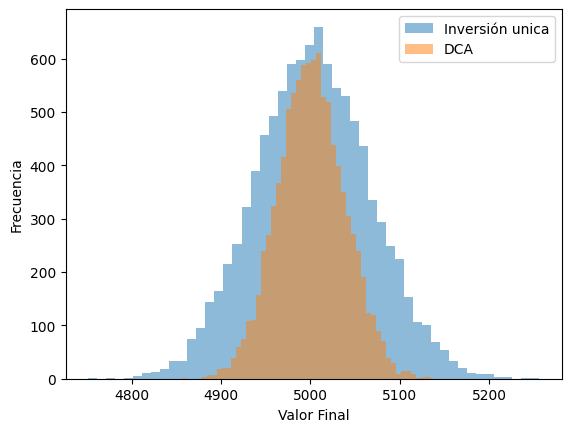

In [33]:
plt.hist(precios_final_unica, bins=50, alpha=0.5, label="Inversión unica")
plt.hist(precios_final_dca, bins=50, alpha=0.5, label="DCA")

plt.xlabel("Valor Final")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

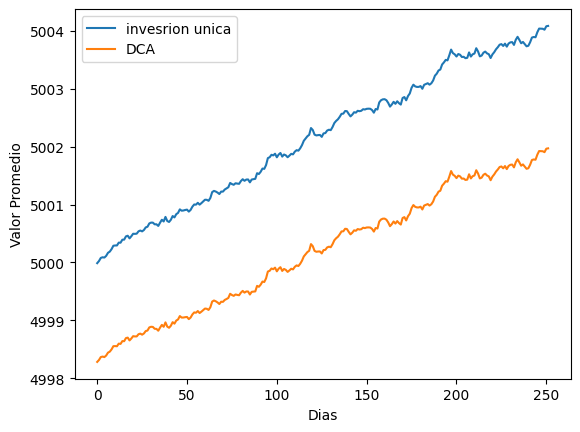

In [26]:
plt.plot(trayectoria_prom_unica, label="invesrion unica")
plt.plot(trayectoria_prom_dca, label="DCA")

plt.xlabel("Dias")
plt.ylabel("Valor Promedio")
plt.legend()
plt.show()

**Estrategias de inversion**
- Inversion iunica: Funciona mejor cuando el mercado sube de forma constante, porque todo el dinero empieza a trabajar desde el inicio.
- Aportaciones periódicas (DCA)-> Ayudan a reducir el riesgo de invertir justo en un mal momento, suavizan la volatilidad y protegen aun mas  en mercados bajistas o inestables.

Entonces que se puede concluir con est ...
- La inversión periodica conviene en mercados volátiles o bajistas.
- La inversión unica es mejor cuando el mercado mantiene una tendencia alcista clara.

 En otras palabras si el mercado sube - concienen invertiri todo al incio , por otro lado si el mercado es inciertoentonces convienen DCA pues reduce el riesgo sistematico. 

